# Feature Engineering: Handling Missing Numerical Data
### Univariate Imputation: Mean, Median, Arbitrary Value, and End-of-Distribution Imputation

---

### Scope & Focus of This Notebook
- **Primary Topic**: Univariate Imputation for numerical features — replacing missing values using data from the same feature without deleting rows.
- **What You Will Learn**:
  1. What univariate imputation is and why it preserves 100% of observations.
  2. Manual implementation of Mean and Median imputation using pure Python and pandas `.fillna()`.
  3. When to choose Mean vs. Median (symmetric vs. skewed distributions).
  4. The 3 main side effects of Mean/Median imputation:
     - Deflated variance (artificially squeezed data).
     - Distribution distortion (unnatural peak at the center).
     - Weakened covariance and correlation.
  5. Arbitrary Value Imputation (using constants like `-1` or `999` to signal missingness to tree models).
  6. End-of-Distribution Imputation (using the 3-sigma boundary $\mu + 3\sigma$ or IQR fence).
  7. Production workflow using Scikit-Learn's `SimpleImputer` with strict leakage prevention (`fit` on train, `transform` on test).
  8. Head-to-Head Model Experiment: Comparing CCA vs. Median vs. Arbitrary vs. End-of-Tail imputation on test accuracy.
- **What We Will NOT Cover Here**:
  - Multivariate imputation (KNN Imputer, MICE / IterativeImputer) will be taught in upcoming dedicated modules.
  - Categorical data imputation (Most Frequent / Mode / Missing Category) is covered in the next topic.

---

## 1. Setup & Environment Verification

### What are we doing?
We import data manipulation, visualization, and machine learning libraries, and load the Titanic dataset with simple path checking.

#### What do these libraries do here?
- `pandas`: Tabular data handling and simple imputation using `.fillna()`.
- `numpy`: Numerical calculations and handling missing values (`np.nan`).
- `matplotlib.pyplot` & `seaborn`: Plotting distribution curves (KDE) and boxplots before and after imputation.
- `sklearn`: Preprocessing (`SimpleImputer`, `StandardScaler`), model evaluation (`RandomForestClassifier`, `train_test_split`, `accuracy_score`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Clean visualization settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load Titanic dataset with fallback path
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values in Age:  {df['Age'].isnull().sum()} out of {len(df)} rows")


Loaded Titanic Dataset: 891 rows, 12 columns
Missing values in Age:  177 out of 891 rows


## 2. Manual Understanding on a Simple Toy Dataset

### What are we doing?
Before working with large datasets, we create a tiny 5-row dataset to see how Mean and Median imputation calculate replacement values line by line.

#### The Toy Data:
`Age = [20, 25, NaN, 30, 35]`

- Non-null values: `20, 25, 30, 35`
- Sum: $20 + 25 + 30 + 35 = 110$
- Mean: $110 / 4 = 27.5$
- Median: $(25 + 30) / 2 = 27.5$


In [2]:
# 1. Create simple toy DataFrame
toy = pd.DataFrame({
    'Age': [20.0, 25.0, np.nan, 30.0, 35.0]
})

print("--- Original Toy Data ---")
print(toy)

# Calculate mean and median of non-missing values
mean_val = toy['Age'].mean()
median_val = toy['Age'].median()

# Fill missing values using pandas .fillna()
toy['Age_Mean'] = toy['Age'].fillna(mean_val)
toy['Age_Median'] = toy['Age'].fillna(median_val)

print("\n--- Toy Data After Imputation ---")
print(toy)


--- Original Toy Data ---
    Age
0  20.0
1  25.0
2   NaN
3  30.0
4  35.0

--- Toy Data After Imputation ---
    Age  Age_Mean  Age_Median
0  20.0      20.0        20.0
1  25.0      25.0        25.0
2   NaN      27.5        27.5
3  30.0      30.0        30.0
4  35.0      35.0        35.0


## 3. Mean vs. Median: The Outlier Sensitivity Test

### What are we doing?
We examine what happens when data contains an extreme outlier (like an executive salary).

#### Key Concept:
- **Mean is sensitive to outliers**: Extreme values pull the mean upward.
- **Median is robust to outliers**: Extreme values do not shift the middle rank.


In [3]:
# Salary dataset with one huge outlier (CEO salary)
salary_data = pd.DataFrame({
    'Salary': [30000.0, 35000.0, 40000.0, 45000.0, 1000000.0, np.nan]
})

sal_mean = salary_data['Salary'].mean()
sal_median = salary_data['Salary'].median()

print(f"Calculated Mean Salary:   ₹{sal_mean:,.2f}  (Pulled upward by ₹10,00,000!)")
print(f"Calculated Median Salary: ₹{sal_median:,.2f}  (Represents typical employee salary)")

salary_data['Filled_Mean'] = salary_data['Salary'].fillna(sal_mean)
salary_data['Filled_Median'] = salary_data['Salary'].fillna(sal_median)

print("\n--- Salary Imputation Comparison ---")
print(salary_data)


Calculated Mean Salary:   ₹230,000.00  (Pulled upward by ₹10,00,000!)
Calculated Median Salary: ₹40,000.00  (Represents typical employee salary)

--- Salary Imputation Comparison ---
      Salary  Filled_Mean  Filled_Median
0    30000.0      30000.0        30000.0
1    35000.0      35000.0        35000.0
2    40000.0      40000.0        40000.0
3    45000.0      45000.0        45000.0
4  1000000.0    1000000.0      1000000.0
5        NaN     230000.0        40000.0


## 4. Mean and Median Imputation on Titanic `Age`

### What are we doing?
In the Titanic dataset, `Age` has 177 missing values (19.87% missing).
We compute the mean and median age on the non-null passengers and create two clean imputed columns using simple pandas code:

```python
df['Age_Mean'] = df['Age'].fillna(df['Age'].mean())
df['Age_Median'] = df['Age'].fillna(df['Age'].median())
```


In [4]:
# Calculate mean and median
age_mean = df['Age'].mean()
age_median = df['Age'].median()

print(f"Titanic Mean Age:   {age_mean:.2f} years")
print(f"Titanic Median Age: {age_median:.2f} years")

# Simple pandas imputation
df['Age_Mean'] = df['Age'].fillna(age_mean)
df['Age_Median'] = df['Age'].fillna(age_median)

# Verify zero missing values remain
print(f"Remaining nulls in Age_Mean:   {df['Age_Mean'].isnull().sum()}")
print(f"Remaining nulls in Age_Median: {df['Age_Median'].isnull().sum()}")


Titanic Mean Age:   29.70 years
Titanic Median Age: 28.00 years
Remaining nulls in Age_Mean:   0
Remaining nulls in Age_Median: 0


## 5. Diagnostic Check 1: Measuring Variance Reduction

### What are we doing?
We check whether replacing 177 missing ages with the exact same number reduced the feature's variance.

#### Why does variance decrease?
Because all 177 imputed rows have a difference from the mean of $(29.70 - 29.70)^2 = 0$. Adding zero-variance points artificially deflates the overall variance of the column!


In [5]:
var_orig = df['Age'].var()
var_mean = df['Age_Mean'].var()
var_median = df['Age_Median'].var()

print(f"Original Age Variance:       {var_orig:.2f}")
print(f"Mean-Imputed Variance:       {var_mean:.2f}  (Dropped by {((var_orig - var_mean)/var_orig * 100):.1f}%)")
print(f"Median-Imputed Variance:     {var_median:.2f}  (Dropped by {((var_orig - var_median)/var_orig * 100):.1f}%)")


Original Age Variance:       211.02
Mean-Imputed Variance:       169.05  (Dropped by 19.9%)
Median-Imputed Variance:     169.51  (Dropped by 19.7%)


## 6. Diagnostic Check 2: Visualizing the Distribution Shape

### What are we doing?
We plot the Kernel Density Estimation (KDE) curve of `Age` before and after imputation using simple `seaborn` plotting code.

#### What does the plot show?
Notice the sharp artificial spike near Age 28–30 in the imputed curves. Piling 177 identical values onto the center distorts the natural shape of the distribution.


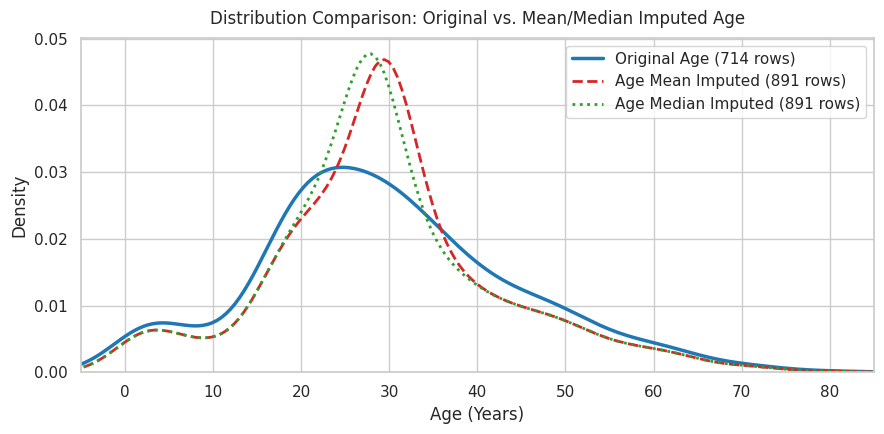

In [6]:
plt.figure(figsize=(9, 4.5))

sns.kdeplot(df['Age'], label='Original Age (714 rows)', color='#1f77b4', linewidth=2.5)
sns.kdeplot(df['Age_Mean'], label='Age Mean Imputed (891 rows)', color='#d62728', linewidth=2, linestyle='--')
sns.kdeplot(df['Age_Median'], label='Age Median Imputed (891 rows)', color='#2ca02c', linewidth=2, linestyle=':')

plt.title('Distribution Comparison: Original vs. Mean/Median Imputed Age', fontsize=12, pad=10)
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.xlim(-5, 85)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Diagnostic Check 3: Covariance and Correlation with `Fare`

### What are we doing?
We check whether replacing missing ages with a constant weakened the relationship between `Age` and `Fare`.

#### What does the output mean?
Because we added constant ages while fares varied naturally, the covariance drops from $73.85$ down to $59.57$, slightly diluting the linear relationship between the two features.


In [7]:
cov_orig = df['Age'].cov(df['Fare'])
cov_mean = df['Age_Mean'].cov(df['Fare'])

corr_orig = df['Age'].corr(df['Fare'])
corr_mean = df['Age_Mean'].corr(df['Fare'])

print("--- Covariance with Fare ---")
print(f"Original Age & Fare Covariance:     {cov_orig:.2f}")
print(f"Mean-Imputed Age & Fare Covariance: {cov_mean:.2f}")

print("\n--- Pearson Correlation (r) with Fare ---")
print(f"Original Correlation:               {corr_orig:.4f}")
print(f"Mean-Imputed Correlation:           {corr_mean:.4f}")


--- Covariance with Fare ---
Original Age & Fare Covariance:     73.85
Mean-Imputed Age & Fare Covariance: 59.16

--- Pearson Correlation (r) with Fare ---
Original Correlation:               0.0961
Mean-Imputed Correlation:           0.0916


## 8. Arbitrary Value Imputation

### What are we doing?
Instead of calculating a mean or median, we fill missing values with a deliberate constant that cannot occur naturally:
- For `Age`: We choose `-1` or `99` (or `-999`).

#### Why is this used?
In tree-based algorithms (Decision Trees, Random Forests), choosing `-1` lets the model create an explicit decision split:
$$\text{If Age} \le 0 \implies \text{Passenger has missing age cohort}$$

#### Simple Code:
```python
df['Age_Arbitrary'] = df['Age'].fillna(-1)
```


In [8]:
# Fill missing Age with -1
df['Age_Arbitrary'] = df['Age'].fillna(-1)

print(f"Nulls in Age_Arbitrary: {df['Age_Arbitrary'].isnull().sum()}")
print("Sample values including imputed -1:")
print(df[['Age', 'Age_Arbitrary']].loc[df['Age'].isnull()].head(5))


Nulls in Age_Arbitrary: 0
Sample values including imputed -1:
    Age  Age_Arbitrary
5   NaN           -1.0
17  NaN           -1.0
19  NaN           -1.0
26  NaN           -1.0
28  NaN           -1.0


## 9. End-of-Distribution Imputation

### What are we doing?
Instead of picking an arbitrary number like `999` out of thin air, we place missing values at the **far extreme tail of the feature's natural distribution**:

$$\text{Extreme Upper Boundary} = \text{Mean} + 3 \times \text{Standard Deviation}$$

#### Why is this better than picking 999?
Because it scales automatically with the data. If the feature is in thousands or millions, the 3-sigma boundary automatically reflects that scale.


In [9]:
# Calculate 3-sigma upper boundary
mean_val = df['Age'].mean()
std_val = df['Age'].std()

upper_3sigma = mean_val + 3 * std_val
print(f"Age Mean:               {mean_val:.2f}")
print(f"Age Standard Deviation: {std_val:.2f}")
print(f"Calculated 3-Sigma End: {upper_3sigma:.2f} years")

# Fill missing values with the 3-sigma tail value
df['Age_End_of_Tail'] = df['Age'].fillna(upper_3sigma)

print(f"Nulls in Age_End_of_Tail: {df['Age_End_of_Tail'].isnull().sum()}")
print("Sample values imputed at extreme tail:")
print(df[['Age', 'Age_End_of_Tail']].loc[df['Age'].isnull()].head(5))


Age Mean:               29.70
Age Standard Deviation: 14.53
Calculated 3-Sigma End: 73.28 years
Nulls in Age_End_of_Tail: 0
Sample values imputed at extreme tail:
    Age  Age_End_of_Tail
5   NaN         73.27861
17  NaN         73.27861
19  NaN         73.27861
26  NaN         73.27861
28  NaN         73.27861


### Visualizing All 4 Imputation Strategies Side-by-Side

### What are we doing?
We plot KDE curves for all 4 methods to clearly see how each strategy places imputed values along the axis:
- **Mean & Median**: Pile points at the center (~28–30).
- **Arbitrary (-1)**: Creates a new peak below zero.
- **End-of-Tail (~73)**: Creates a new peak at the far right edge.


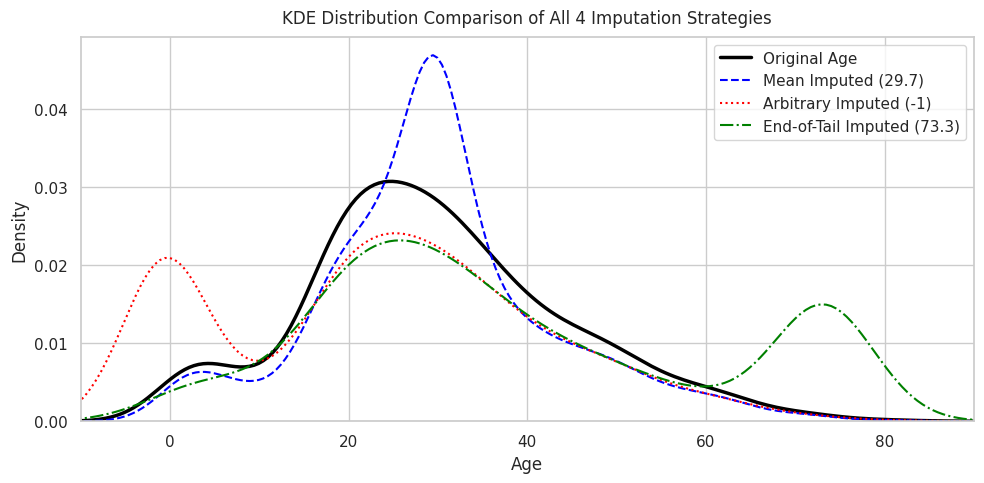

In [10]:
plt.figure(figsize=(10, 5))

sns.kdeplot(df['Age'], label='Original Age', color='black', linewidth=2.5)
sns.kdeplot(df['Age_Mean'], label='Mean Imputed (29.7)', color='blue', linestyle='--')
sns.kdeplot(df['Age_Arbitrary'], label='Arbitrary Imputed (-1)', color='red', linestyle=':')
sns.kdeplot(df['Age_End_of_Tail'], label='End-of-Tail Imputed (73.3)', color='green', linestyle='-.')

plt.title('KDE Distribution Comparison of All 4 Imputation Strategies', fontsize=12, pad=10)
plt.xlabel('Age')
plt.ylabel('Density')
plt.xlim(-10, 90)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Production ML Workflow with Scikit-Learn `SimpleImputer`

### Meaningful Function Explanation: `SimpleImputer(strategy='median', fill_value=None)`

1. **What is this function?**  
   Scikit-Learn's standard transformer for imputing missing values in tabular datasets.
2. **Why did we use it?**  
   To build clean, leakage-proof machine learning pipelines that learn imputation statistics strictly from the training data and apply them to unseen test data.
3. **What does it take as input?**  
   - `strategy`: `'mean'`, `'median'`, `'most_frequent'`, or `'constant'`.
   - `fill_value`: When `strategy='constant'`, specifies the custom value to fill (e.g. `-1`).
4. **What does it return?**  
   A fitted transformer object that transforms raw NumPy arrays or DataFrames with nulls into complete numeric arrays.
5. **How does it work internally?**  
   - During `fit(X_train)`: Computes and stores the summary statistic for each feature in the `statistics_` attribute.
   - During `transform(X)`: Replaces all `np.nan` entries with the stored values from `statistics_`.
6. **Why did we choose this approach?**  
   It eliminates data leakage by ensuring test data is never used to calculate means or medians.
7. **What will happen if we don't use it?**  
   Manually calling `df['col'].mean()` before splitting leaks test data information into training.
8. **Concrete Before / After Example:**  
   - Input `X_train`: `[20, NaN, 30]` $\implies$ `fit()` stores `median = 25.0`.  
   - Input `X_test`: `[NaN, 40]` $\implies$ `transform()` outputs `[25.0, 40]`.


In [11]:
# 1. Prepare features and target
features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']
target = 'Survived'

X = df[features]
y = df[target]

# 2. Split FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"Missing in X_train Age: {X_train['Age'].isnull().sum()}")
print(f"Missing in X_test Age:  {X_test['Age'].isnull().sum()}")

# 3. Create and fit SimpleImputer STRICTLY on X_train
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)

print(f"\nLearned Training Median for Age: {imputer.statistics_[1]:.2f} years")

# 4. Transform both training and test data
X_train_clean = imputer.transform(X_train)
X_test_clean = imputer.transform(X_test)

# Verify zero nulls remain in transformed arrays
print(f"Any nulls in cleaned X_train: {np.isnan(X_train_clean).any()}")
print(f"Any nulls in cleaned X_test:  {np.isnan(X_test_clean).any()}")


X_train shape: (712, 5), X_test shape: (179, 5)
Missing in X_train Age: 137
Missing in X_test Age:  40

Learned Training Median for Age: 28.50 years
Any nulls in cleaned X_train: False
Any nulls in cleaned X_test:  False


## 11. Head-to-Head Model Experiment: Comparing Imputation Strategies

### What are we doing?
We benchmark a Random Forest Classifier across 4 imputation approaches:
1. **Complete Case Analysis (CCA)**: Dropping incomplete rows on training set.
2. **Mean Imputation**: Replacing nulls with training mean.
3. **Median Imputation**: Replacing nulls with training median.
4. **Arbitrary Value Imputation (`-1`)**: Flagging nulls with `-1`.
5. **End-of-Distribution Imputation**: Placing nulls at $\mu + 3\sigma$.

We train using identical splits and hyperparameters (`n_estimators=100, max_depth=5, random_state=42`) and compare test accuracy.


In [12]:
results = {}

# Strategy 1: Complete Case Analysis (dropping missing rows on train)
train_clean_idx = X_train.dropna().index
X_tr_cca = X_train.loc[train_clean_idx]
y_tr_cca = y_train.loc[train_clean_idx]

rf_cca = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_cca.fit(X_tr_cca, y_tr_cca)

# Evaluate on complete test rows
test_clean_idx = X_test.dropna().index
results['1. Complete Case Analysis (CCA)'] = accuracy_score(
    y_test.loc[test_clean_idx], rf_cca.predict(X_test.loc[test_clean_idx])
)

# Strategy 2: Mean Imputation
imp_mean = SimpleImputer(strategy='mean')
X_tr_mean = imp_mean.fit_transform(X_train)
X_te_mean = imp_mean.transform(X_test)
rf_mean = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_tr_mean, y_train)
results['2. Mean Imputation'] = accuracy_score(y_test, rf_mean.predict(X_te_mean))

# Strategy 3: Median Imputation
imp_med = SimpleImputer(strategy='median')
X_tr_med = imp_med.fit_transform(X_train)
X_te_med = imp_med.transform(X_test)
rf_med = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_tr_med, y_train)
results['3. Median Imputation'] = accuracy_score(y_test, rf_med.predict(X_te_med))

# Strategy 4: Arbitrary Value Imputation (-1)
imp_arb = SimpleImputer(strategy='constant', fill_value=-1)
X_tr_arb = imp_arb.fit_transform(X_train)
X_te_arb = imp_arb.transform(X_test)
rf_arb = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_tr_arb, y_train)
results['4. Arbitrary Value (-1)'] = accuracy_score(y_test, rf_arb.predict(X_te_arb))

# Strategy 5: End-of-Distribution Imputation (mean + 3*std of train)
train_end = X_train['Age'].mean() + 3 * X_train['Age'].std()
X_tr_end = X_train.copy()
X_te_end = X_test.copy()
X_tr_end['Age'] = X_tr_end['Age'].fillna(train_end)
X_te_end['Age'] = X_te_end['Age'].fillna(train_end)

rf_end = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_tr_end, y_train)
results['5. End-of-Distribution (3-Sigma)'] = accuracy_score(y_test, rf_end.predict(X_te_end))

# Print summary table
print("=" * 60)
print(f"{'Strategy':<35} | {'Test Accuracy':<15}")
print("=" * 60)
for strat, acc in results.items():
    print(f"{strat:<35} | {acc * 100:.2f}%")
print("=" * 60)


Strategy                            | Test Accuracy  
1. Complete Case Analysis (CCA)     | 69.78%
2. Mean Imputation                  | 70.39%
3. Median Imputation                | 70.39%
4. Arbitrary Value (-1)             | 70.39%
5. End-of-Distribution (3-Sigma)    | 69.83%


---

## What We Learned
- **Core Concept of Univariate Imputation**: Replaces missing values using a single statistical summary from the same column, preserving 100% of rows.
- **Mean vs. Median Selection**:
  - Use **Mean** when data is bell-shaped and symmetric with no extreme outliers.
  - Use **Median** when data is skewed or contains outliers (robust to extremes).
- **The Cost of Imputation**:
  - Artificially **reduces variance** (adds points with zero deviation).
  - Creates a **sharp density spike** around the imputed value.
  - Weakens covariance and linear correlation with other variables.
- **Arbitrary Value Imputation**: Replaces nulls with an unnatural constant (like `-1`) to allow tree algorithms to isolate missingness.
- **End-of-Distribution Imputation**: Dynamically places missing values at the 3-sigma tail boundary ($\mu + 3\sigma$), providing a scaled alternative to arbitrary constants.
- **Data Leakage Prevention**: Imputation parameters (mean, median, 3-sigma) must be calculated **strictly on `X_train`** and used to transform both `X_train` and `X_test`.

---

## Important Takeaways
1. **Never fit imputers on the whole dataset**: Always do `train_test_split` first, then fit on `X_train`.
2. **Default to Median for real-world continuous data**: Real-world metrics (income, prices, age) are rarely perfectly symmetric.
3. **Always check the 4 validation pillars**: Variance ratio, KDE distribution shape, correlation preservation, and boxplot outliers.
4. **Arbitrary values are model-dependent**: Great for Decision Trees and Random Forests; disastrous for Logistic Regression and KNN.

---

## Common Mistakes
1. **Using Mean on heavily skewed data**: Pulls the imputed value away from the true center of the population.
2. **Fitting SimpleImputer on the test set**: Causes data leakage and artificially inflates test scores.
3. **Using Arbitrary constants (`-1` or `999`) with linear models**: Severely distorts slopes and gradient calculations.
4. **Assuming imputation is consequence-free**: Forgetting that variance is deflated when many identical values are added.

---

## Final Mental Model

```text
                     Missing Numerical Feature
                                 │
                                 ▼
                     Is missingness meaningful?
                    (Does missingness carry signal?)
                                 │
                 ┌───────────────┴───────────────┐
                 ▼                               ▼
             YES (MNAR)                      NO (MCAR / MAR)
                 │                               │
                 ▼                               ▼
       Tree-Based Model?                Check Distribution Shape
                 │                               │
        ┌────────┴────────┐              ┌───────┴───────┐
        ▼                 ▼              ▼               ▼
  End-of-Tail         Arbitrary        Normal          Skewed
(μ + 3σ or IQR)      Value (-1)         Mean           Median
```
